# Modelagem com auto ML e LLM para predição de sucesso em campanha de telemarketing

_Objetivo: Classificar se um cliente irá (ou não) realizar um depósito, levando em conta informações de campanhas de marketing via telefone._

**Dataset:** [Bank Marketing (UCI)](https://archive.ics.uci.edu/dataset/222/bank+marketing)

## Setups iniciais

In [1]:
REDUCE_DATASETS = False
PERC_DATASET = 0.01
TEST_SIZE = 0.3

PATH_DATASET_BANK_FULL = 'datasets/bank-full.csv'
PATH_INFOS_BANK_FULL = 'datasets/bank-names.txt'

REPORT_FILE_PATH = 'reports/report_eda_v1.html'
TRAINED_MODEL_PATH = 'trained_models/opt_model_pipeline__full_dataset_v1.pkl'

### Carrega bibliotecas

In [2]:
import pickle
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import IFrame
from rich import print

from ydata_profiling import ProfileReport
import phik

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from flaml import AutoML

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq

load_dotenv()
%matplotlib inline
pd.set_option('display.max_columns', None)
np.random.seed(42)

## Prepara dataset

In [3]:
df_bank_full = pd.read_csv(PATH_DATASET_BANK_FULL, sep=';')

if REDUCE_DATASETS:
    df_bank_full = df_bank_full.sample(n=round(PERC_DATASET*df_bank_full.shape[0]), random_state=42)

print('Full dataset:')
print(df_bank_full.shape)
display(df_bank_full.head())

Full dataset:

(45211, 17)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Divide dataset em treino e teste

### Define features

In [4]:
cols_to_remove = ['y']

In [5]:
cols_features = [col for col in df_bank_full.columns if col not in cols_to_remove]
print(cols_features)

[
    'age',
    'job',
    'marital',
    'education',
    'default',
    'balance',
    'housing',
    'loan',
    'contact',
    'day',
    'month',
    'duration',
    'campaign',
    'pdays',
    'previous',
    'poutcome'
]

In [6]:
df_train, df_test = train_test_split(df_bank_full, test_size=TEST_SIZE, stratify=df_bank_full['y'], random_state=42)
x_train = df_train.drop(columns=cols_to_remove)
y_train = df_train['y']

x_test = df_test.drop(columns='y')
y_test = df_test['y']

In [7]:
df_train.describe()

,age,balance,day,duration,campaign,pdays,previous
count,31647.000000,31647.000000,31647.000000,31647.000000,31647.000000,31647.000000,31647.000000
mean,40.883022,1363.589535,15.806712,258.755143,2.760040,39.869498,0.584795
std,10.621809,3070.235315,8.331080,259.880162,3.104999,99.674113,2.490925
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,74.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,451.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1427.500000,21.000000,318.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### EDA com YData Profiling

In [8]:
profile = ProfileReport(df_train, title='Report dataset Bank Marketing', explorative=True)

profile.to_file(REPORT_FILE_PATH)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████| 17/17 [00:00<00:00, 2555.30it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
IFrame(src=REPORT_FILE_PATH, width=1200, height=800)

**Resultados esperados**

<img src='imgs/features_quality.png'>


### Explorando distribuições e correlações

In [10]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31647 entries, 13382 to 3184
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        31647 non-null  int64 
 1   job        31647 non-null  object
 2   marital    31647 non-null  object
 3   education  31647 non-null  object
 4   default    31647 non-null  object
 5   balance    31647 non-null  int64 
 6   housing    31647 non-null  object
 7   loan       31647 non-null  object
 8   contact    31647 non-null  object
 9   day        31647 non-null  int64 
 10  month      31647 non-null  object
 11  duration   31647 non-null  int64 
 12  campaign   31647 non-null  int64 
 13  pdays      31647 non-null  int64 
 14  previous   31647 non-null  int64 
 15  poutcome   31647 non-null  object
dtypes: int64(7), object(9)
memory usage: 5.1+ MB


In [11]:
y_train.value_counts(dropna=False)

y
no     27945
yes     3702
Name: count, dtype: int64

In [12]:
df_train_yes = df_train[df_train.y=='yes']
df_train_no = df_train[df_train.y=='no']

In [13]:
def compare_values_cat(col: str) -> None:
    df_counts = pd.concat(
        [
            df_train[col].value_counts(),
            df_train_yes[col].value_counts(),
            df_train_no[col].value_counts()
        ],
        axis=1
    )
    df_counts.columns = ['total', 'yes', 'no']
    
    df_counts = df_counts.fillna(0).astype(int)
    
    df_counts['%yes'] = (df_counts['yes'] / df_counts['total'] * 100).round(2)
    df_counts['%no']  = (df_counts['no']  / df_counts['total'] * 100).round(2)
    
    df_counts = df_counts.sort_values('%yes', ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    df_counts[['total', 'yes', 'no']].plot(kind='barh', ax=axes[0])
    axes[0].set_title(f'{col} distribution')
    
    axes[1].axis('off')
    table = axes[1].table(
        cellText=df_counts.values,
        colLabels=df_counts.columns,
        rowLabels=df_counts.index,
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)
    
    plt.tight_layout()
    plt.show()

In [14]:
cols_to_check = ['poutcome', 'month', 'contact', 'job', 'housing']

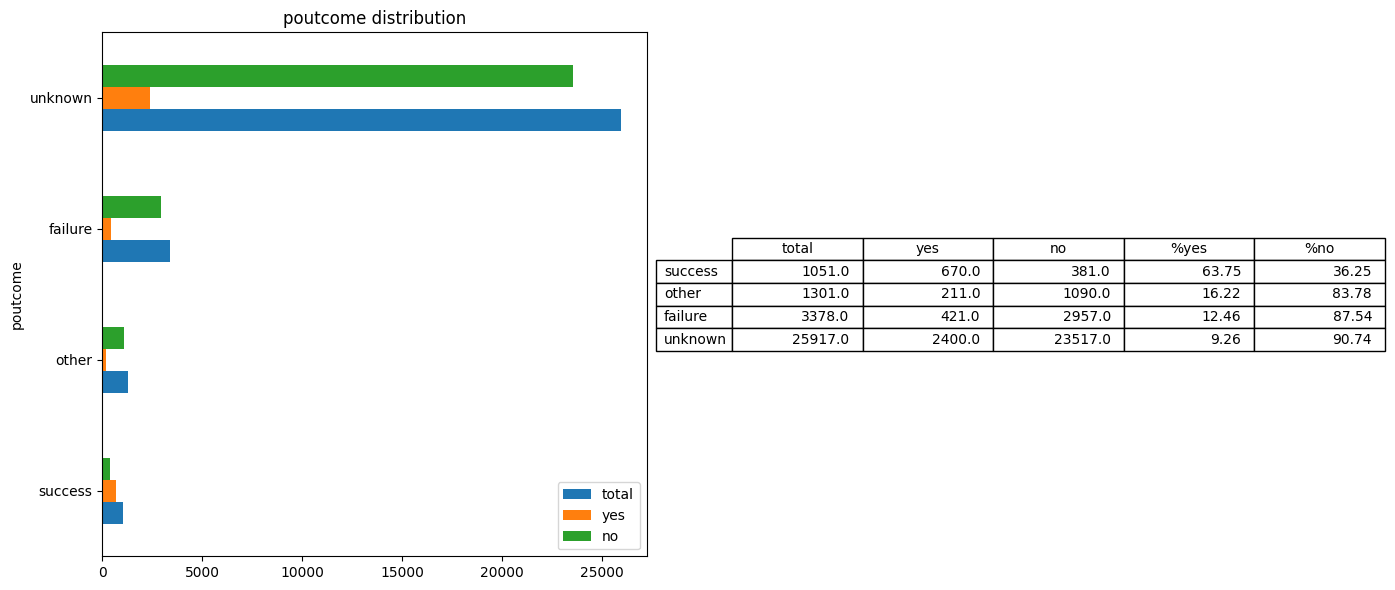

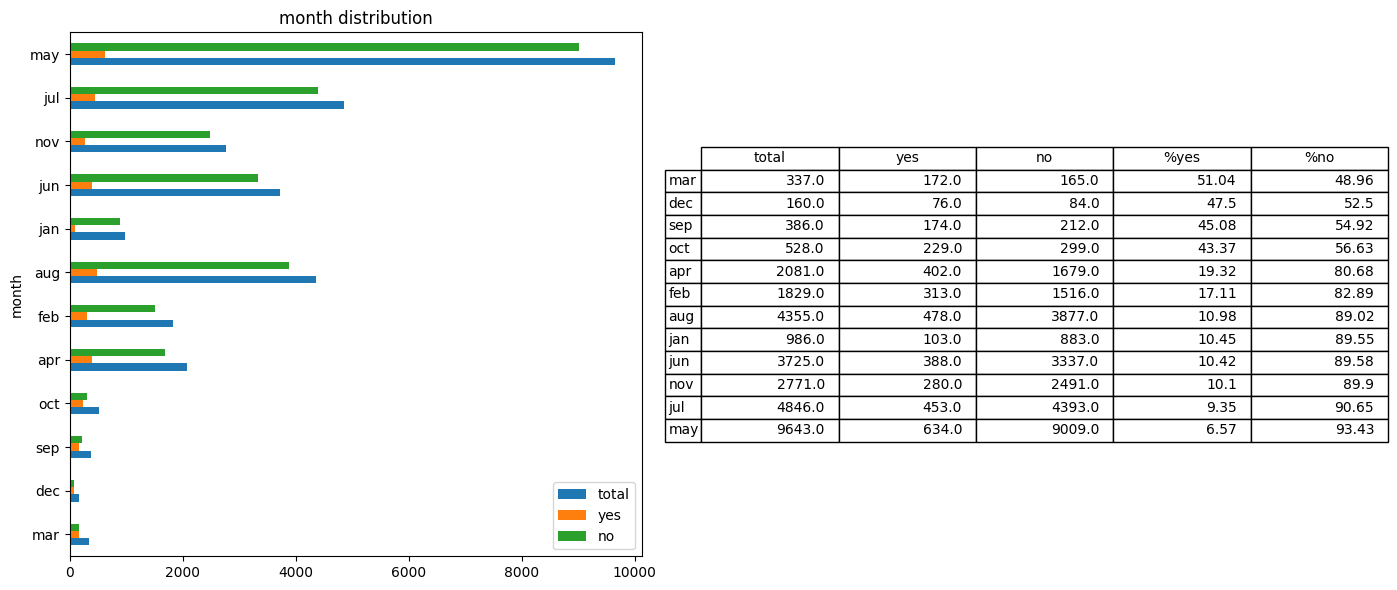

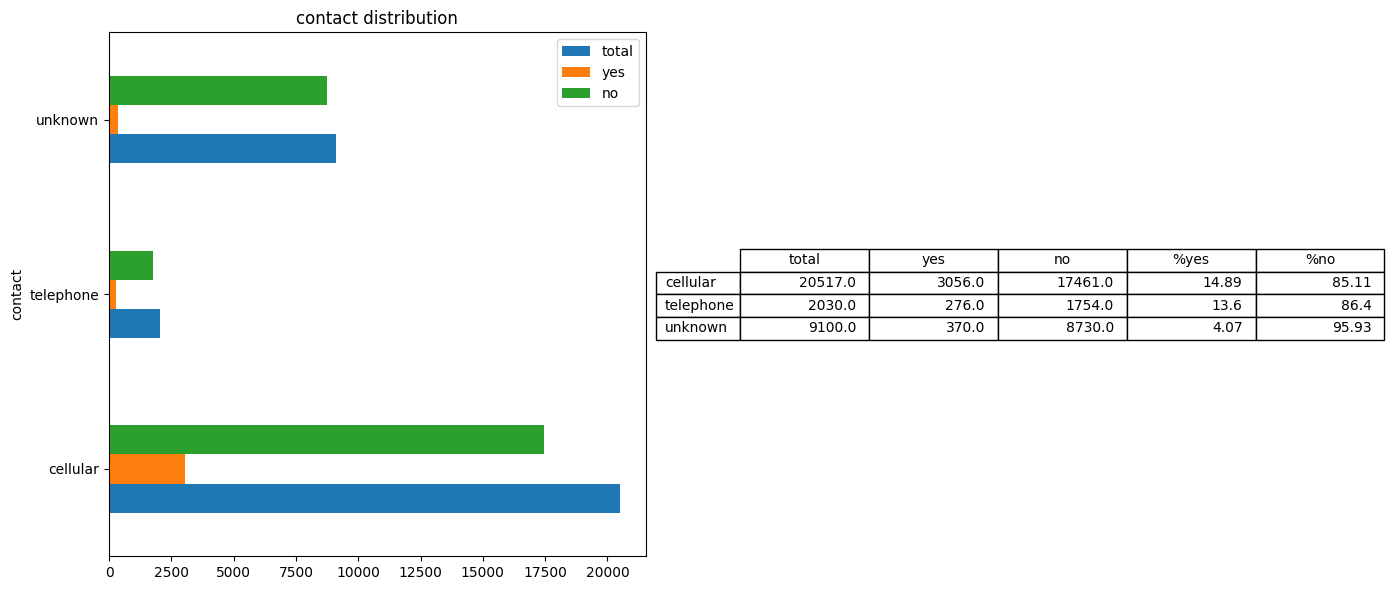

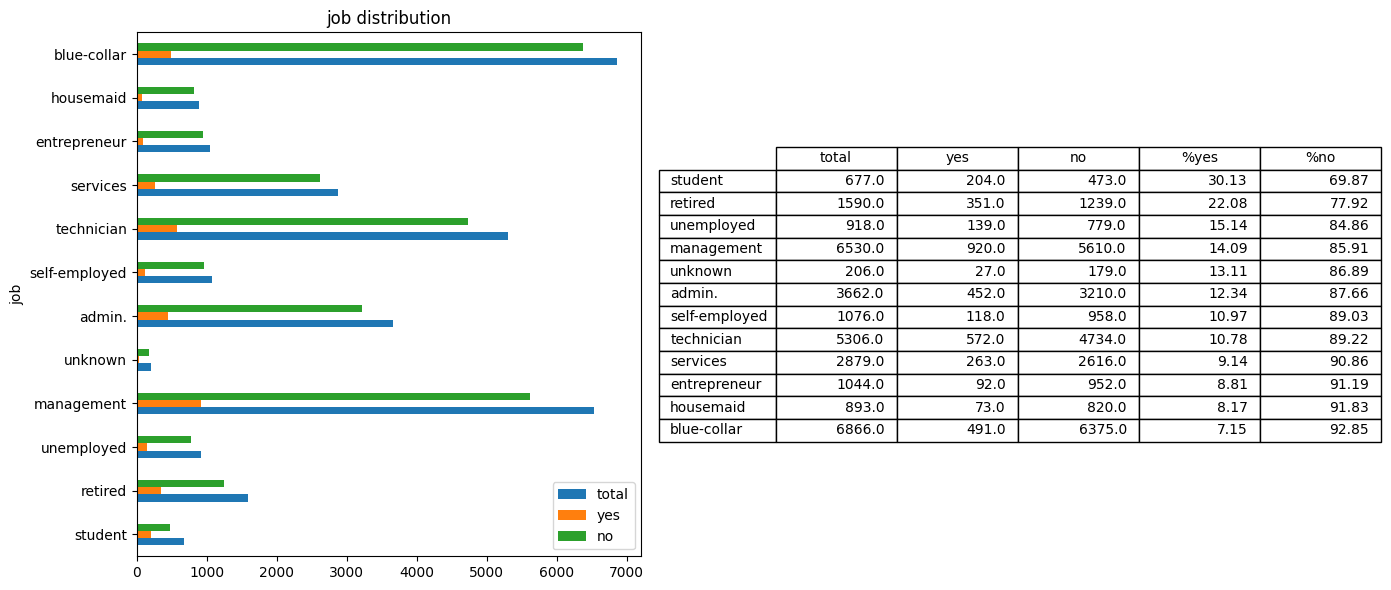

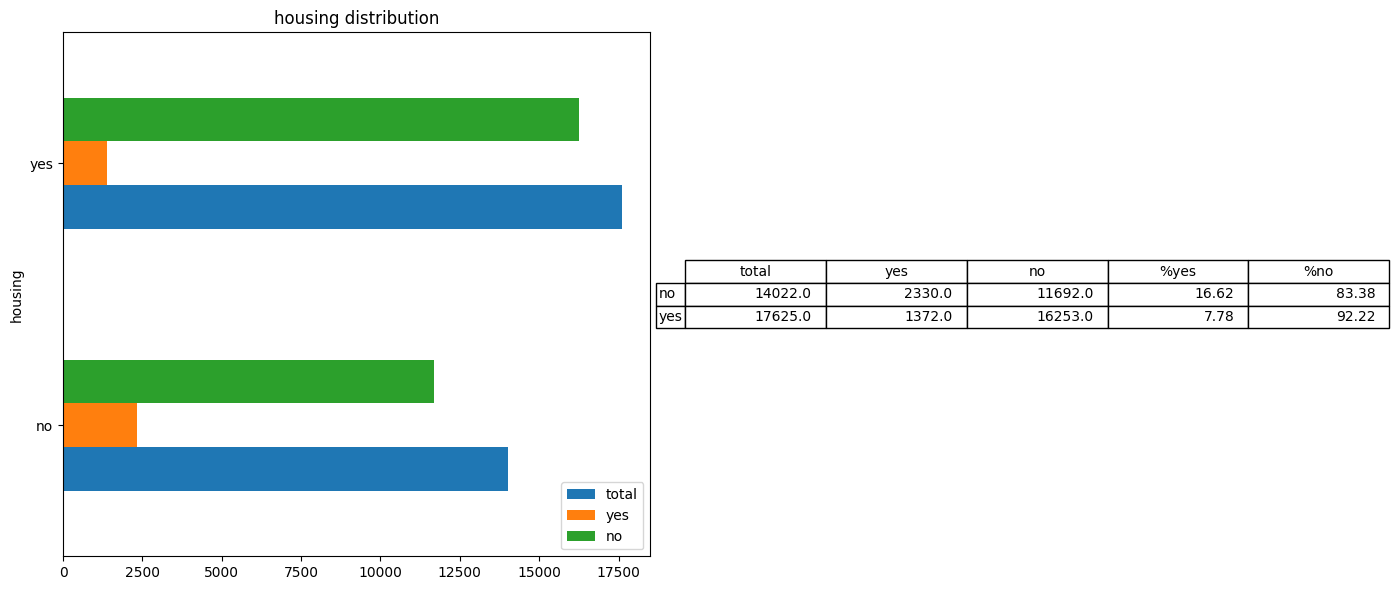

In [15]:
for col in cols_to_check:
    compare_values_cat(col=col)

In [16]:
df_train_corr = df_train.phik_matrix()
df_train_corr

interval columns not set, guessing: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
age,1.000000,0.511164,0.480203,0.223261,0.020033,0.136437,0.298571,0.082530,0.263736,0.100803,0.225747,0.045875,0.042783,0.106669,0.000000,0.106023,0.202089
job,0.511164,1.000000,0.419335,0.772614,0.039764,0.077817,0.366093,0.139635,0.323092,0.101057,0.361825,0.025334,0.028373,0.102525,0.000000,0.138786,0.178375
marital,0.480203,0.419335,1.000000,0.129224,0.011230,0.033165,0.012428,0.031426,0.139774,0.042347,0.152893,0.033865,0.002603,0.052758,0.000000,0.033000,0.042610
education,0.223261,0.772614,0.129224,1.000000,0.029585,0.069529,0.172838,0.120109,0.128347,0.069724,0.228178,0.000000,0.019829,0.075343,0.018086,0.090455,0.108653
default,0.020033,0.039764,0.011230,0.029585,1.000000,0.046038,0.000000,0.119096,0.016160,0.009121,0.073183,0.000000,0.020652,0.044877,0.000000,0.059064,0.038057
balance,0.136437,0.077817,0.033165,0.069529,0.046038,1.000000,0.058343,0.080693,0.086467,0.071807,0.144760,0.000000,0.000000,0.057946,0.000000,0.037881,0.066430
housing,0.298571,0.366093,0.012428,0.172838,0.000000,0.058343,1.000000,0.067638,0.130568,0.167668,0.642324,0.002783,0.030079,0.217546,0.008537,0.214390,0.212471
loan,0.082530,0.139635,0.031426,0.120109,0.119096,0.080693,0.067638,1.000000,0.007243,0.047628,0.234022,0.023083,0.000000,0.041340,0.013471,0.085807,0.101324
contact,0.263736,0.323092,0.139774,0.128347,0.016160,0.086467,0.130568,0.007243,1.000000,0.144400,0.790576,0.056881,0.047074,0.314887,0.005913,0.217132,0.091126
day,0.100803,0.101057,0.042347,0.069724,0.009121,0.071807,0.167668,0.047628,0.144400,1.000000,0.594424,0.030067,0.163581,0.239421,0.012234,0.133459,0.100196


In [17]:
df_train_corr['y'].sort_values(ascending=False)

y            1.000000
poutcome     0.451372
duration     0.372241
month        0.330097
pdays        0.246535
housing      0.212471
age          0.202089
job          0.178375
education    0.108653
loan         0.101324
day          0.100196
contact      0.091126
balance      0.066430
campaign     0.063268
marital      0.042610
default      0.038057
previous     0.019257
Name: y, dtype: float64

## Treinamento

### Encode das colunas não numéricas

In [18]:
cat_cols = x_train.select_dtypes(include='object').columns
num_cols = x_train.select_dtypes(include='number').columns

In [19]:
onehot_encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
)

### Treina modelo

In [20]:
automl = AutoML()

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', onehot_encoder, cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)
pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('model', automl)
    ]
)

#### Treina modelo com FLAML AutoML

In [22]:
pipeline.fit(
    X=x_train[cols_features],
    y=y_train,
    model__task='classification',
    model__metric='f1',
    model__time_budget=100,
    model__verbose=1,
)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Modelo ótimo

In [23]:
# modelos candidatos
pd.DataFrame(pipeline.named_steps['model'].best_config_per_estimator)

,lgbm,rf,xgboost,extra_tree,xgb_limitdepth,sgd,catboost,lrl1
n_estimators,101.000000,5,181.000000,12,92.000000,NaN,8192.0,NaN
num_leaves,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min_child_samples,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
learning_rate,0.289465,NaN,0.172332,NaN,0.207426,constant,0.1,NaN
log_max_bin,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
colsample_bytree,0.956410,NaN,0.671870,NaN,1.000000,NaN,NaN,NaN
reg_alpha,0.007836,NaN,0.017418,NaN,0.016852,NaN,NaN,NaN
reg_lambda,2.291598,NaN,0.756390,NaN,0.002052,NaN,NaN,NaN
max_features,NaN,0.540882,NaN,0.614257,NaN,NaN,NaN,NaN
max_leaves,NaN,151,468.000000,763,NaN,NaN,NaN,NaN


In [24]:
print('\n=== Modelo ótimo ===\n')
print(f'Name: {pipeline.named_steps['model'].best_estimator}')
print(f'Loss: {pipeline.named_steps['model'].best_loss}')

=== Modelo ótimo ===

Name: xgb_limitdepth

Loss: 0.3976261127596439

### Exporta modelo treinado

In [25]:
with open(TRAINED_MODEL_PATH, 'wb') as f:
    pickle.dump(pipeline, f)

## Predições com modelo treinado

In [26]:
def compute_metrics(x: pd.DataFrame, y: pd.Series, suffix: str = None) -> pd.DataFrame:
    y_pred = pipeline.predict(x[cols_features])
    y_prob = pipeline.predict_proba(x[cols_features])[:,1]
    
    y_num = [1 if i == 'yes' else 0 for i in y]
    y_pred_num = [1 if i == 'yes' else 0 for i in y_pred]

    metrics = {
        f'f1_{suffix}': f1_score(y_num, y_pred_num),
        f'accuracy_{suffix}': accuracy_score(y_num, y_pred_num),
        f'precision_{suffix}': precision_score(y_num, y_pred_num),
        f'recall_{suffix}': recall_score(y_num, y_pred_num),
        f'roc_auc_{suffix}': roc_auc_score(y_num, y_prob),
    }

    return pd.DataFrame(metrics, index=['metrics'])

In [27]:
train_metrics = compute_metrics(x=x_train, y=y_train, suffix='train')
test_metrics = compute_metrics(x=x_test, y=y_test, suffix='test')

In [28]:
print(f'x_train.shape: {x_train.shape}')
print(f'x_test.shape: {x_test.shape}')

x_train.shape: (31647, 16)

x_test.shape: (13564, 16)

### Tabela com métricas

In [29]:
all_metrics = pd.concat([train_metrics, test_metrics], axis=1).T
all_metrics

,metrics
f1_train,0.789380
accuracy_train,0.955130
precision_train,0.875329
recall_train,0.718801
roc_auc_train,0.980541
f1_test,0.550550
accuracy_test,0.906591
precision_test,0.629870
recall_test,0.488973
roc_auc_test,0.930335


### Gráfico comparativo

In [30]:
def plot_train_test_metrics(metrics_train: pd.DataFrame, metrics_test: pd.DataFrame):
    metrics = [col.replace('_train','').replace('_test','') for col in metrics_train.columns]

    train_values = metrics_train.iloc[0].values
    test_values  = metrics_test.iloc[0].values

    x = np.arange(len(metrics))
    width = 0.3

    fig, ax = plt.subplots(figsize=(8, 5))
    rects1 = ax.bar(x - width/2, train_values, width, label='Train', color='darkblue')
    rects2 = ax.bar(x + width/2, test_values, width, label='Test', color='darkorange')

    ax.set_ylabel('Score')
    ax.set_xlabel('Métrica')
    ax.set_title('Métricas Treino vs Teste')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()

    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),
                    textcoords='offset points',
                    ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

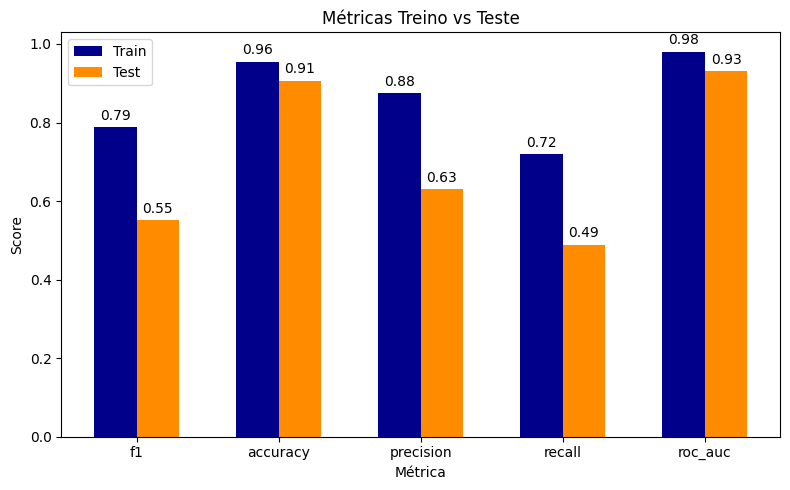

In [31]:
plot_train_test_metrics(train_metrics, test_metrics)

## Explicação da performance com LLM 

In [32]:
template = '''
You are an expert in evaluating machine learning performance.

Given the input in JSON format containing the calculated performance 
metrics, explain in clear, simple, and technical language the performance of our model.

Provide the response in bullet points.

Ipunt (JSON):
{all_model_metrics}
'''

prompt_template = PromptTemplate.from_template(
    template=template
)

In [33]:
llm_model = ChatGroq(
    # model='qwen/qwen3-32b',
    model='llama-3.3-70b-versatile',
    temperature=0,
    max_tokens=300,
    timeout=None,
    max_retries=2,
    verbose=False
)

In [34]:
system_prompt = 'How did the model perform on the training and test datasets?'
user_prompt = prompt_template.format(all_model_metrics=all_metrics.to_json())
messages = [
    SystemMessage(content=system_prompt),
    HumanMessage(content=user_prompt)
]

response = llm_model.invoke(messages)
print(f'🤖: {response.content}')

🤖: Here's a clear and simple explanation of the model's performance in bullet points:

* **Training Performance:**
  * The model achieved an **F1 score of 0.79**, indicating a good balance between precision and recall on the 
training dataset.
  * **Accuracy** on the training dataset was **95.51%**, showing that the model correctly classified most of the 
training samples.
  * **Precision** was **0.88**, meaning that about 88% of the samples predicted as positive were actually positive.
  * **Recall** was **0.72**, indicating that the model was able to detect about 72% of the actual positive samples.
  * The **ROC-AUC score** was **0.98**, showing excellent discrimination between positive and negative classes on 
the training dataset.

* **Testing Performance:**
  * The model achieved an **F1 score of 0.55** on the test dataset, indicating a lower balance between precision 
and recall compared to the training dataset.
  * **Accuracy** on the test dataset was **90.66%**, still showing good overall performance, but slightly lower 
than on the training dataset.
  * **Precision** was **0.63**, meaning that about 63% of the samples predicted as positive were actually positive.
  * **Recall** was **0.49**, indicating that the model was able to detect about 49% of the actual positive samples,
which is lower than on the training

## Próximos passos

- Explorar questões sobre este dataset presentes no seguinte artigo:
**"Moro, S., Cortez, P., & Rita, P. (2014). A data-driven approach to predict the success of bank telemarketing. Decis. Support Syst., 62, 22-31".**

<img src='imgs/table1.png' size='40%'>


## Informações sobre o dataset Bank Marketing (UCI)

In [35]:
with open(PATH_INFOS_BANK_FULL, 'r', encoding='utf-8') as f:
    content = f.read()
print(content)

Citation Request:
  This dataset is public available for research. The details are described in [Moro et al., 2011]. 
  Please include this citation if you plan to use this database:

  [Moro et al., 2011] S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An 
Application of the CRISP-DM Methodology. 
  In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 
117-121, Guimarães, Portugal, October, 2011. EUROSIS.

  Available at:  http://hdl.handle.net/1822/14838
                 http://www3.dsi.uminho.pt/pcortez/bib/2011-esm-1.txt

1. Title: Bank Marketing

2. Sources
   Created by: Paulo Cortez (Univ. Minho) and Sérgio Moro (ISCTE-IUL) @ 2012
   
3. Past Usage:

  The full dataset was described and analyzed in:

  S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM 
Methodology. 
  In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 
117-121, Guimarães, 
  Portugal, October, 2011. EUROSIS.

4. Relevant Information:

   The data is related with direct marketing campaigns of a Portuguese banking institution. 
   The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required,
   in order to access if the product (bank term deposit) would be (or not) subscribed. 

   There are two datasets: 
      1) bank-full.csv with all examples, ordered by date (from May 2008 to November 2010).
      2) bank.csv with 10% of the examples (4521), randomly selected from bank-full.csv.
   The smallest dataset is provided to test more computationally demanding machine learning algorithms (e.g. SVM).

   The classification goal is to predict if the client will subscribe a term deposit (variable y).

5. Number of Instances: 45211 for bank-full.csv (4521 for bank.csv)

6. Number of Attributes: 16 + output attribute.

7. Attribute information:

   For more information, read [Moro et al., 2011].

   Input variables:
   # bank client data:
   1 - age (numeric)
   2 - job : type of job (categorical: 
"admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services") 
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or 
widowed)
   4 - education (categorical: "unknown","secondary","primary","tertiary")
   5 - default: has credit in default? (binary: "yes","no")
   6 - balance: average yearly balance, in euros (numeric) 
   7 - housing: has housing loan? (binary: "yes","no")
   8 - loan: has personal loan? (binary: "yes","no")
   # related with the last contact of the current campaign:
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular") 
  10 - day: last contact day of the month (numeric)
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  12 - duration: last contact duration, in seconds (numeric)
   # other attributes:
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last 
contact)
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, 
-1 means client was not previously contacted)
  15 - previous: number of contacts performed before this campaign and for this client (numeric)
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  Output variable (desired target):
  17 - y - has the client subscribed a term deposit? (binary: "yes","no")

8. Missing Attribute Values: None